In [1]:
import numpy as np
import glitterin

nndir="/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/nnmodels/"
# Create the scattering wrapper
producer = glitterin.user.ScatteringProducer(
    nndir=nndir
)

# Specify the desired scattering quantities
producer.setup(['Cext', 'Z11'])

# Create the inputs
x = np.array([0.1])
n = np.array([1.5])
k = np.array([0.01])
theta = np.linspace(0, 180, 181)
w = 1e-4 # [cm]

# Call the producer and the results will be a dictionary
result = producer(x, n, k, theta, w, xtype='vol', outtype='dict')


Loaded model for ems
Loaded model for N11
Loaded model for Qext


/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Load Producer
Loaded model for N44
Loaded model for N33
Loaded model for N12
Loaded model for N22
Loaded model for N34
Loaded model for ems
Loaded model for N11
Loaded model for Qext
Plotting


/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/glitterin_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


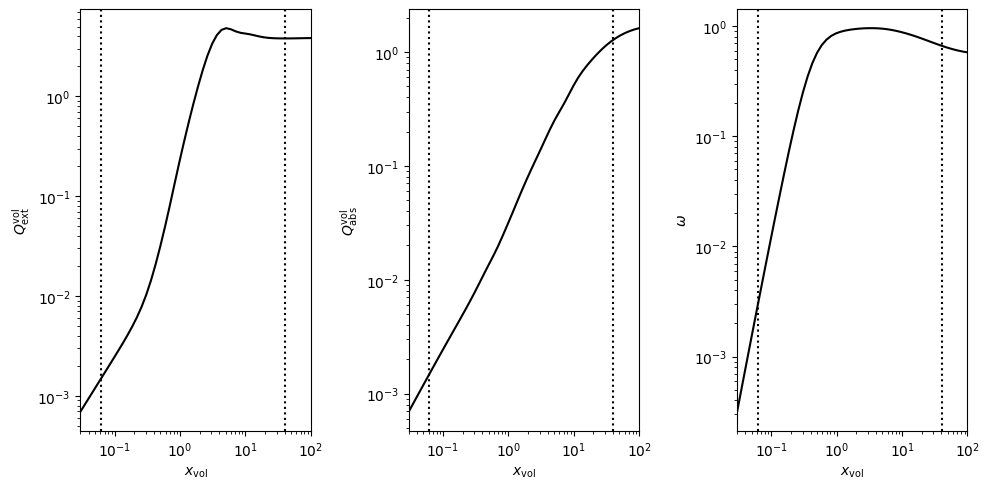

In [2]:
"""
This is an example script on how to calculate quantities from glitterin

"""
# import numpy as np
import matplotlib.pyplot as plt

# # import sys
# # sys.path.append('..')
# import glitterin

# Load Producer
print('Load Producer')

# Generate the ScatteringProducer object
# nndir = 'path/to/nnmodels'
producer = glitterin.user.ScatteringProducer(nndir=nndir)

# Now we want to decide what qantities we want. 
producer.setup(['Cext', 'Cabs', 'albedo', 'Z11', 'Z12', 'N12', 'N22', 'N33', 'N34', 'N44'])

# The inputs (x,n,k) have to be matching 1d arrays. 
# theta should be its own 1d array. 
xvol = np.geomspace(0.03, 100, 50)
re_m = 1.5 + np.zeros_like(xvol)
im_m = 0.01 + np.zeros_like(xvol)
theta = np.linspace(0, 180, 91)

# The wavelength scales the cross-section.
# the cross-sectional values will be in units that are the squared of the wavelength units
# e.g., if wavelength is in cm, then Cext will be in cm^2 and Z11 will be in cm^2 per ster
w = 1e-4 # [cm]

# Call the producer to generate the output
# the output is a dictionary with quantities defined in the setup
# xtype allows the user to determine what kind of "radius" we're considering. Either the radius of volume equivalent sphere, radius of projected area equivalent circle, or radius of the enclosing sphere. 
out = producer(xvol, re_m, im_m, theta, w, xtype='vol', outtype='dict')

# this is the volume equivalent grain size 
avol = w / 2 / np.pi * xvol

# These are the Q efficiency factors. 
# It's easier in the user side to explicitly determine what kind of radius we are using for the efficiency. 
# For radiation transfer, it doesn't matter. Only the actual Cext, etc, matters
Qextvol = out['Cext'] / (np.pi*avol**2)
Qabsvol = out['Cabs'] / (np.pi*avol**2)

# The minimum xenc of the training data is 0.1
# We can figure out what the volume equivalent x that is with
min_xvol = glitterin.user.xvol_from_xenc(0.1)

# the maximum xvol of the training data depends on the refractive index
max_xvol = glitterin.user.max_xvol_from_nk(re_m[0], im_m[0])

print('Plotting')
fig, axes = plt.subplots(1,3,sharex=True,sharey=False,squeeze=True,figsize=(10,5))

ax = axes[0]
ax.plot(xvol, Qextvol, 'k-')
ax.set_ylabel(r'$Q_{\text{ext}}^{\text{vol}}$')

ax = axes[1]
ax.plot(xvol, Qabsvol, 'k-')
ax.set_ylabel(r'$Q_{\text{abs}}^{\text{vol}}$')

ax = axes[2]
ax.plot(xvol, out['albedo'], 'k-')
ax.set_ylabel(r'$\omega$')

for ax in axes:
    ax.set_xlim(xvol[0], xvol[-1])
    ax.set_xscale('log')
    ax.set_xlabel(r'$x_{\text{vol}}$')

    ax.set_yscale('log')

    # denote the max xvol in the training data
    ax.axvline(x=max_xvol, color='k', linestyle=':')

    # the min xvol
    ax.axvline(x=min_xvol, color='k', linestyle=':')

fig.tight_layout()
plt.show()


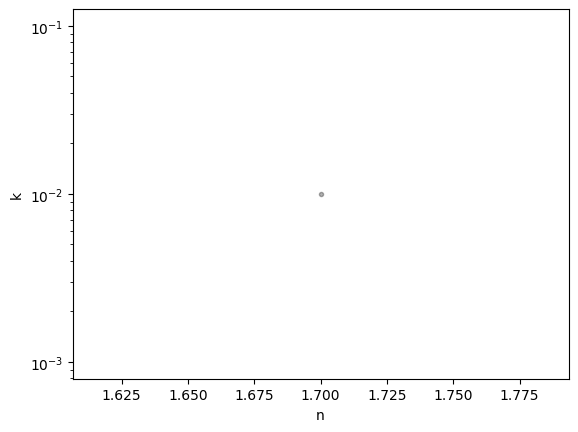

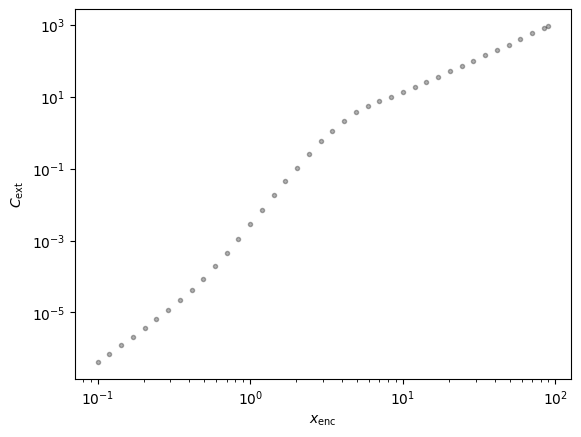

In [3]:
"""
Example script to read the training data which can be downloaded at:
https://doi.org/10.7910/DVN/QZE3D7

See example_read_visualization.py on how to recover Cext, Cabs, etc

"""
# import numpy as np
# import matplotlib.pyplot as plt

# import sys
# sys.path.append('..')
# import glitterin

# Read a visualization data
dir_1 = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/glitterin/dataverse_files/vis_n1.7_k0.01"
out = glitterin.data.read_dataset(dir_1, quant='all', load_uncertainty=True)

# input properties of the dust
xenc = out['par']['xsize']
re_m = out['par']['re_m']
im_m = out['par']['im_m']

# The ensemble-averaged quantity that were all normalized
avg = out['avg']

w = 1. # [cm]

renc = w / 2 / np.pi * xenc

# Recover the cross-sectional quantities in cm^2
Cext = avg.Cext * np.pi * renc**2

# Plot the distribution of (n,k)
plt.plot(re_m, im_m, 'k.', alpha=0.3)
plt.yscale('log')
plt.xlabel('n')
plt.ylabel('k')
plt.show()

# Plot the Cext as a function of xenc
plt.plot(xenc, Cext, 'k.', alpha=0.3)
plt.xscale('log'), plt.yscale('log')
plt.xlabel(r'$x_{\text{enc}}$')
plt.ylabel(r'$C_{\text{ext}}$')
plt.show()


Plotting


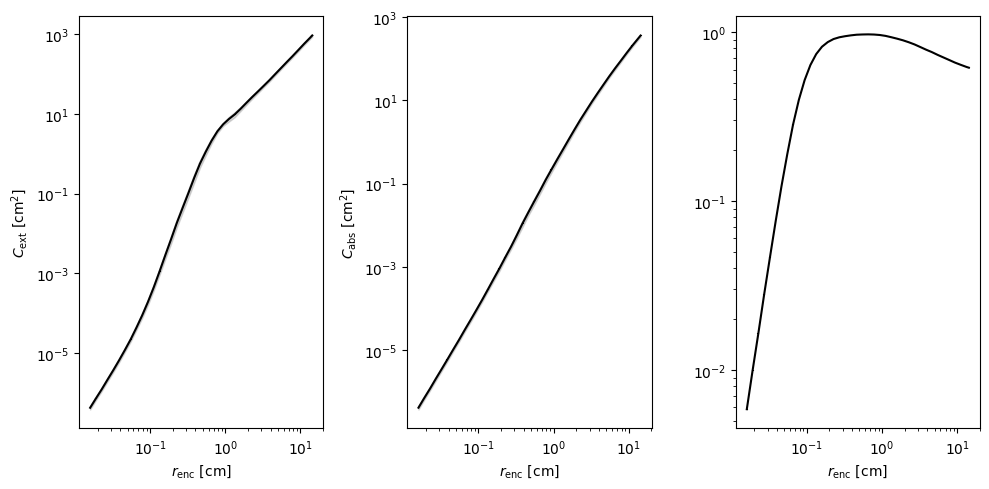

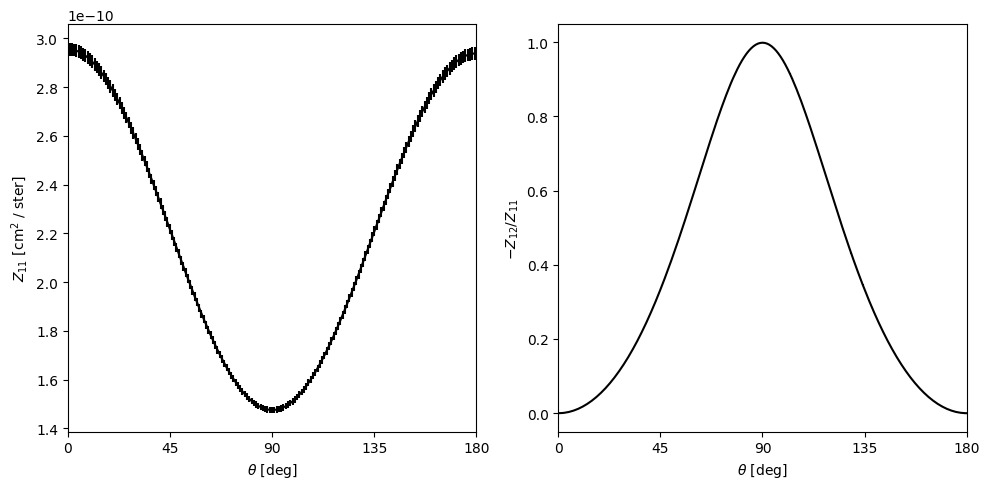

In [4]:
"""
example script to read the visualization data which can be downloaded at:
https://doi.org/10.7910/DVN/CWLYZL

Note that for these data, the cross-sections are normalized by pi aenc^2 as a default
"""
# import numpy as np
# import matplotlib.pyplot as plt

# import sys
# sys.path.append('..')
# import glitterin

# Read a visualization data
# dir_1 = 'path/to/export'
out = glitterin.data.read_dataset(dir_1, quant='all', load_uncertainty=True)

# input properties of the dust
xenc = out['par']['xsize']
re_m = out['par']['re_m']
im_m = out['par']['im_m']

# The ensemble-averaged quantity that were all normalized
# We can access the quantities as a property directly
avg = out['avg']

# The standard deviation of the ensemble which were also normalized
std = out['std']

# To un-normalize them, we need to know the wavelength
# The units of the cross-section is the units of the wavelength squared
w = 1. # [cm]

# And determine the radius of the enclosing sphere
renc = w / 2 / np.pi * xenc

# The following recovers the cross-sectional quantities in cm^2
Cext = avg.Cext * np.pi * renc**2
Cabs = avg.Cabs * np.pi * renc**2
Z11 = avg.Z11 * np.pi * renc**2

# The uncertainties of the average should be scaled in the same way
d_Cext = avg.d_Cext * np.pi * renc**2
d_Cabs = avg.d_Cabs * np.pi * renc**2

d_Z11 = avg.d_Z11 * np.pi * renc**2

# Also the standard deviation of the ensemble quantity
std_Cext = std.Cext * np.pi * renc**2
std_Cabs = std.Cabs * np.pi * renc**2

# Certain quantities are not affected by normalization 
albedo = avg.albedo
d_albedo = avg.d_albedo

N12 = avg.N12
d_N12 = avg.d_N12

print('Plotting')

# Plot 1
fig, axes = plt.subplots(1,3,sharex=True,sharey=False,squeeze=True,figsize=(10,5))
ax = axes[0]
ax.errorbar(renc, Cext, yerr=d_Cext, fmt='', color='k')
ax.fill_between(renc, Cext-std_Cext, Cext+std_Cext, color='grey', alpha=0.3)
ax.set_yscale('log')
ax.set_ylabel(r'$C_{\text{ext}}$ [cm$^{2}$]')

ax = axes[1]
ax.errorbar(renc, Cabs, yerr=d_Cabs, fmt='', color='k')
ax.fill_between(renc, Cabs-std_Cabs, Cabs+std_Cabs, color='grey', alpha=0.3)
ax.set_yscale('log')
ax.set_ylabel(r'$C_{\text{abs}}$ [cm$^{2}$]')

ax = axes[2]
ax.errorbar(renc, albedo, yerr=d_albedo, fmt='', color='k')
ax.set_yscale('log')

for ax in axes:
    ax.set_xscale('log')
    ax.set_xlabel(r'$r_{\text{enc}}$ [cm]')

fig.tight_layout()
plt.show()

# Plot 2: angular quantities
# the scattering angle is through avg.ang and is in units of degrees
# The Zij 2d matrices are in shape of (theta, xenc)
fig, axes = plt.subplots(1,2,sharex=True,sharey=False,squeeze=True,figsize=(10,5))
ax = axes[0]
ax.errorbar(avg.ang, Z11[:,0], yerr=d_Z11[:,0], color='k')
ax.set_ylabel(r'$Z_{11}$ [cm$^{2}$ / ster]')

ax = axes[1]
ax.errorbar(avg.ang, N12[:,0], yerr=d_N12[:,0], color='k')
ax.set_ylabel(r'$- Z_{12} / Z_{11}$')

for ax in axes:
    ax.set_xlabel(r'$\theta$ [deg]')
    ax.set_xticks(np.arange(0, 181, 45))
    ax.set_xlim(0, 180)

fig.tight_layout()
plt.show()


In [5]:
# import numpy as np
import timeit

import sys
sys.path.append('..')
# import glitterin

# Load Producer
print('Load Producer')

# producer = glitterin.user.ScatteringProducer(nndir='/home/zylin/coding/glitterin')
producer.setup(['Cext', 'Cabs', 'Z11', 'Z12', 'N12', 'N22', 'N33', 'N34', 'N44'])

def my_function():
    n_sample = 100
    out = producer(
        np.array([1] * n_sample), 
        np.array([1.7] * n_sample), 
        np.array([0.01] * n_sample), 
        np.linspace(0, 180, 181), 
        2 * np.pi)
    return out

print('Start timeit')

number = 20
setup_code = 'from __main__ import my_function'
execution_time = timeit.timeit('my_function()', setup=setup_code, number=number)
print(f'Execution time: {execution_time} seconds')

avg_time = execution_time / number
print(f'Average time: {avg_time} seconds')

Load Producer
Start timeit
Execution time: 4.766840291034896 seconds
Average time: 0.2383420145517448 seconds
